--- Avaliando User-based CF ---
Treinando e avaliando para k=10...
-> k=10: MAE = 0.7636
Treinando e avaliando para k=20...
-> k=20: MAE = 0.7467
Treinando e avaliando para k=40...
-> k=40: MAE = 0.7403

--- Avaliando Improved SVD ---
Treinando e avaliando para Fatores=20...
-> Fatores=20: MAE = 0.7235
Treinando e avaliando para Fatores=30...
-> Fatores=30: MAE = 0.7202
Treinando e avaliando para Fatores=40...
-> Fatores=40: MAE = 0.7202

--- Avaliando Precision e Recall (usando os melhores hiperparâmetros) ---
Treinando o melhor modelo User-Based...
User-Based (k=40): Precision = 0.0067, Recall = 0.0049
Treinando o melhor modelo SVD...
SVD (Fatores=30): Precision = 0.0790, Recall = 0.0510

Gerando gráfico de análise de hiperparâmetros...


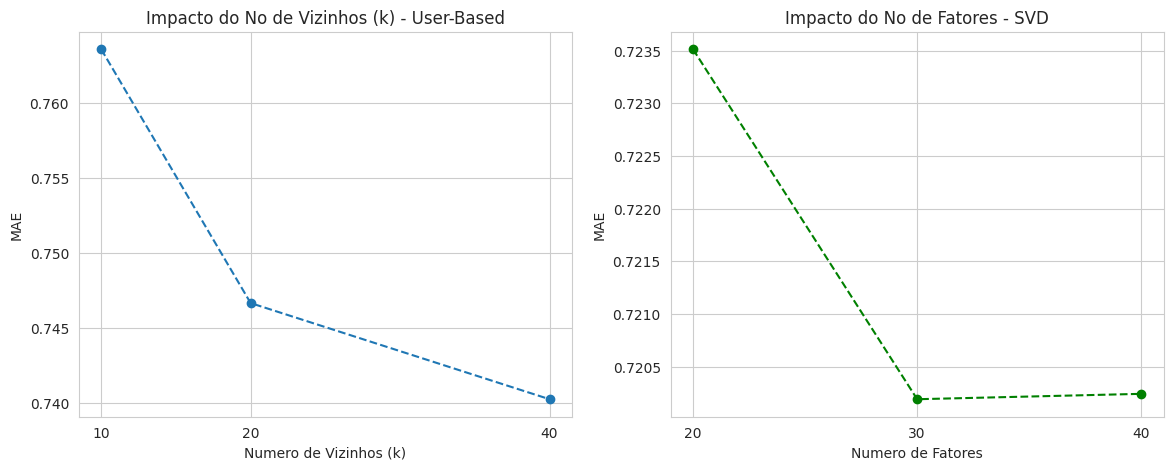

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

class FiltroColaborativoUsuario:
    def __init__(self, k=40):
        self.k = k
        self.matriz_similaridade = None
        self.matriz_treino = None
        self.media_geral_treino = 0

    def _calcular_similaridade_pearson_manual(self):
        num_usuarios = self.matriz_treino.shape[0]
        matriz_sim = np.zeros((num_usuarios, num_usuarios))

        for u1 in range(num_usuarios):
            for u2 in range(u1, num_usuarios):
                if u1 == u2:
                    matriz_sim[u1, u2] = 1.0
                    continue

                itens_comuns = np.where((self.matriz_treino[u1,:] > 0) & (self.matriz_treino[u2,:] > 0))[0]

                if len(itens_comuns) < 2:
                    sim = 0.0
                else:
                    notas1 = self.matriz_treino[u1, itens_comuns]
                    notas2 = self.matriz_treino[u2, itens_comuns]

                    media1, media2 = np.mean(notas1), np.mean(notas2)
                    numerador = np.sum((notas1 - media1) * (notas2 - media2))
                    denominador = np.sqrt(np.sum((notas1 - media1)**2)) * np.sqrt(np.sum((notas2 - media2)**2))

                    sim = numerador / denominador if denominador != 0 else 0.0

                matriz_sim[u1, u2] = sim
                matriz_sim[u2, u1] = sim
        return matriz_sim

    def treinar(self, dados_treino, n_usuarios, n_itens):
        self.matriz_treino = np.zeros((n_usuarios, n_itens))
        for linha in dados_treino.itertuples():
            self.matriz_treino[linha.user_id-1, linha.item_id-1] = linha.rating

        self.media_geral_treino = dados_treino['rating'].mean()
        self.matriz_similaridade = self._calcular_similaridade_pearson_manual()
        return self

    def prever(self, id_usuario, id_item):
        idx_usuario, idx_item = id_usuario-1, id_item-1

        if np.count_nonzero(self.matriz_treino[idx_usuario, :]) == 0:
            return self.media_geral_treino

        media_usuario_ativo = np.mean(self.matriz_treino[idx_usuario, self.matriz_treino[idx_usuario, :] > 0])
        similaridades_usuario = self.matriz_similaridade[idx_usuario]
        indices_avaliadores = np.where(self.matriz_treino[:, idx_item] > 0)[0]

        if len(indices_avaliadores) == 0:
          return media_usuario_ativo

        vizinhos = []
        for idx_vizinho in indices_avaliadores:
            if idx_vizinho != idx_usuario:
                vizinhos.append((similaridades_usuario[idx_vizinho], idx_vizinho))

        vizinhos.sort(key=lambda x: x[0], reverse=True)

        numerador, denominador = 0, 0
        media_vizinhos_cache = {}
        for sim, idx_vizinho in vizinhos[:self.k]:
            if sim <= 0:
              continue

            nota_vizinho = self.matriz_treino[idx_vizinho, idx_item]

            if idx_vizinho not in media_vizinhos_cache:
                media_vizinhos_cache[idx_vizinho] = np.mean(self.matriz_treino[idx_vizinho, self.matriz_treino[idx_vizinho, :] > 0])
            media_vizinho = media_vizinhos_cache[idx_vizinho]

            numerador += sim * (nota_vizinho - media_vizinho)
            denominador += abs(sim)

        if denominador == 0:
          return media_usuario_ativo

        previsao = media_usuario_ativo + (numerador / denominador)
        return np.clip(previsao, 1, 5)

class SVDRegularizadoMelhorado:
    def __init__(self, num_fatores=20, epocas=25, taxa_aprendizado=0.007, regularizacao=0.02):
        self.num_fatores = num_fatores
        self.epocas = epocas
        self.lr = taxa_aprendizado
        self.reg = regularizacao

    def treinar(self, dados_treino, num_total_usuarios, num_total_itens):
        self.P = np.random.normal(scale=1./self.num_fatores, size=(num_total_usuarios, self.num_fatores))
        self.Q = np.random.normal(scale=1./self.num_fatores, size=(num_total_itens, self.num_fatores))
        self.b_u = np.zeros(num_total_usuarios)
        self.b_i = np.zeros(num_total_itens)
        self.media_global = dados_treino['rating'].mean()

        for epoca in range(self.epocas):
            for linha in dados_treino.sample(frac=1).itertuples():
                u, i, r = linha.user_id-1, linha.item_id-1, linha.rating

                pred = self.media_global + self.b_u[u] + self.b_i[i] + self.P[u].dot(self.Q[i].T)
                erro = r - pred

                self.b_u[u] += self.lr * (erro - self.reg * self.b_u[u])
                self.b_i[i] += self.lr * (erro - self.reg * self.b_i[i])
                P_u_antigo = self.P[u].copy()
                self.P[u] += self.lr * (erro*self.Q[i] - self.reg*P_u_antigo)
                self.Q[i] += self.lr * (erro*P_u_antigo - self.reg*self.Q[i])
        return self

    def prever(self, id_usuario, id_item):
        u, i = id_usuario-1, id_item-1
        pred = self.media_global + self.b_u[u] + self.b_i[i] + self.P[u].dot(self.Q[i].T)
        return np.clip(pred, 1, 5)

def obter_top_n(modelo, id_usuario, total_itens, dados_treino, n=10):
    itens_ja_avaliados = set(dados_treino[dados_treino['user_id'] == id_usuario]['item_id'])
    previsoes = []
    for id_item in range(1, total_itens + 1):
        if id_item not in itens_ja_avaliados:
            previsoes.append((id_item, modelo.prever(id_usuario, id_item)))
    previsoes.sort(key=lambda x: x[1], reverse=True)
    return [id_item for id_item, nota in previsoes[:n]]

def calcular_precisao_recall(modelo, d_treino, d_teste, n_u, n_i, k=10, limiar=4.0):
    itens_relevantes_por_usuario = defaultdict(list)
    for linha in d_teste.itertuples():
        if linha.rating >= limiar:
            itens_relevantes_por_usuario[linha.user_id].append(linha.item_id)

    precisoes, recalls = [], []
    for id_usuario, itens_relevantes in itens_relevantes_por_usuario.items():
        if not itens_relevantes:
          continue
        recomendacoes = obter_top_n(modelo, id_usuario, n_i, d_treino, n=k)
        acertos = len(set(recomendacoes) & set(itens_relevantes))
        precisoes.append(acertos / k)
        recalls.append(acertos / len(itens_relevantes))
    return np.mean(precisoes), np.mean(recalls)

def plotar_analise_hiperparametros(resultados_ub, resultados_svd):
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = [14, 5]
    plt.subplot(1, 2, 1)
    plt.plot(list(resultados_ub.keys()), list(resultados_ub.values()), 'o--')
    plt.title('Impacto do No de Vizinhos (k) - User-Based')
    plt.xlabel('Numero de Vizinhos (k)'); plt.ylabel('MAE')
    plt.xticks(list(resultados_ub.keys()))
    plt.subplot(1, 2, 2)
    plt.plot(list(resultados_svd.keys()), list(resultados_svd.values()), 'o--', color='green')
    plt.title('Impacto do No de Fatores - SVD')
    plt.xlabel('Numero de Fatores'); plt.ylabel('MAE')
    plt.xticks(list(resultados_svd.keys()))
    plt.show()


# Carregar os dados
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
data = pd.read_csv('/content/sample_data/u.data.txt', sep='\t', names=column_names)
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
n_users, n_items = data['user_id'].max(), data['item_id'].max()

# Avaliação do User-based CF para MAE
print("--- Avaliando User-based CF ---")
k_values = [10, 20, 40]
results_ub = {}
for k in k_values:
    print(f"Treinando e avaliando para k={k}...")
    model_ub = FiltroColaborativoUsuario(k=k).treinar(train_data, n_users, n_items)
    predictions = [model_ub.prever(row.user_id, row.item_id) for row in test_data.itertuples()]
    mae = mean_absolute_error(test_data['rating'], predictions)
    results_ub[k] = mae
    print(f"-> k={k}: MAE = {mae:.4f}")
best_k = min(results_ub, key=results_ub.get)

# Avaliação do SVD para MAE
print("\n--- Avaliando Improved SVD ---")
factor_values = [20, 30, 40]
results_svd = {}
for factors in factor_values:
    print(f"Treinando e avaliando para Fatores={factors}...")
    model_svd = SVDRegularizadoMelhorado(num_fatores=factors).treinar(train_data, n_users, n_items)
    predictions = [model_svd.prever(row.user_id, row.item_id) for row in test_data.itertuples()]
    mae = mean_absolute_error(test_data['rating'], predictions)
    results_svd[factors] = mae
    print(f"-> Fatores={factors}: MAE = {mae:.4f}")
best_factors = min(results_svd, key=results_svd.get)

# Avaliação de Precision/Recall para os melhores modelos
print("\n--- Avaliando Precision e Recall (usando os melhores hiperparâmetros) ---")
print("Treinando o melhor modelo User-Based...")
best_model_ub = FiltroColaborativoUsuario(k=best_k).treinar(train_data, n_users, n_items)
p_ub, r_ub = calcular_precisao_recall(best_model_ub, train_data, test_data, n_users, n_items)
print(f"User-Based (k={best_k}): Precision = {p_ub:.4f}, Recall = {r_ub:.4f}")

print("Treinando o melhor modelo SVD...")
best_model_svd = SVDRegularizadoMelhorado(num_fatores=best_factors).treinar(train_data, n_users, n_items)
p_svd, r_svd = calcular_precisao_recall(best_model_svd, train_data, test_data, n_users, n_items)
print(f"SVD (Fatores={best_factors}): Precision = {p_svd:.4f}, Recall = {r_svd:.4f}")

# Gerar o Gráfico com os resultados de MAE
print("\nGerando gráfico de análise de hiperparâmetros...")
plotar_analise_hiperparametros(results_ub, results_svd)

# Nova seção

**To upload the `u.data.data` file:**

1. Click on the folder icon on the left sidebar to open the file browser.
2. Click on the "Upload to session storage" icon.
3. Select the `u.data.txt` file from your local machine and click "Open".
4. The file should now appear in the file browser.